## **CompBioMed Seminars**

**Using Machine Learning for Site of Origin Prediction in Ventricular Arrhythmias from ECGs and Clinical Data**


To run the ECG Data Segmentation section:

Use Python 3.8
Install Torch
Use this command: 
pip install git+https://github.com/guillermo-jimenez/sak.git

Once you have processed the Teknon data and built your design matrix, you can create a Python environment with a more modern version.

### 1. Load Datasets

#### 1.1. .mat Datasets (DS-2496, DS-43, DS-334).

In [15]:
import numpy as np 
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def _handle_sublocation(dSim: dict, 
                        data_key: str, 
                        path: str, 
                        X: np.ndarray, 
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6 #RVOT Free Wall
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-', 'RVOTOther']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:   
            if label[0] in invalid_labels:
                continue
            
            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'
                
                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'

                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'

                elif label[0] == "Summit":
                    label = 'LVOT Summit'
                
                else:
                    label = label[0]

                if label in mapping:
                    y_sub.append(mapping[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub

In [17]:
def _build_binary_target(dSim: dict, 
                         data_key: str) -> np.ndarray:
    """
    Build LV (0) vs RV (1) classification target.
    """

    mapping = {"LV": 0, "RV": 1}
    #Handle typo inconsistency in datasets
    key_name = "LeftRight" if "LeftRight" in dSim[data_key].dtype.names else "LeftRigth"
    
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]))

    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]

    return y

In [18]:
def _load_mat_dataset(path, sample_size, data_key,
                      lead_names, sublocation):
    """
    Internal function to load .mat ECG datasets.
    """
    #dSim has the data at data_key (e.g., QRS_CARTO), and then for each lead, we have a (1, n_patients) list, where each entry is a (n_samples,) array with the ECG signal for that patient and lead.
    dSim = loadmat(path)

    #Number of patients
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients: {n_patients}")

    #Allocate matrix: (patients × (leads * samples))
    X = np.zeros((n_patients, len(lead_names) * sample_size))

    #Build feature matrix
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]

        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze() #Convert to 1D array

            #Safety check
            if signal_1d.ndim != 1:
                raise ValueError(
                    f"Invalid ECG shape at patient {i}, lead {lead}: {signal_1d.shape}"
                )
            #Resample signal to fixed length
            resampled = signal.resample(signal_1d, sample_size).flatten()

            # Place in correct position
            start = iLead * sample_size
            end = (iLead + 1) * sample_size
            X[i, start:end] = resampled

    #Normalize (important for ML stability)
    X = normalize(X, norm="l1")

    #Build targets
    y = _build_binary_target(dSim, data_key)

    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y
    }
  

In [19]:
def load_dataset(path: str, 
                 sample_size: int, 
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):
    """
    Load ECG dataset and return (X, y).

    This function:
    1. Loads raw ECG data
    2. Resamples each lead
    3. Flattens all 12 leads into a single vector per patient
    4. Normalizes the data
    5. Builds target labels

    Parameters
    ----------
    path : str
        Path to .mat file
    sample_size : int
        Number of samples per lead after resampling
    data_key : str
        Key inside .mat file (e.g. 'QRS')
    lead_names : list
        ECG leads to use (default: standard 12-lead)
    sublocation : bool
        If True, also compute sublocation labels
    shuffle : bool
        Whether to shuffle dataset
    random_state : int or None
        Seed for reproducibility

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, n_leads * sample_size)
    y : np.ndarray
        Binary labels (LV=0, RV=1)
    """

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"Loading dataset from: {path}")

    # Load and process raw data
    DB_dict = _load_mat_dataset(path, sample_size, data_key,
                                lead_names, sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]

    # Shuffle if needed
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]

    return X, y

In [20]:
"""#1. Load QRS_Carto2.mat
X_Clinic, y_Clinic = load_dataset('data/QRS_CARTO2.mat', sample_size=10, data_key='QRS_CARTO', lead_names=["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

 """

'#1. Load QRS_Carto2.mat\nX_Clinic, y_Clinic = load_dataset(\'data/QRS_CARTO2.mat\', sample_size=10, data_key=\'QRS_CARTO\', lead_names=["I","II","III","aVR","aVL","aVF",\n                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)\n\n '

In [21]:
#2. Load QRS_Database2.mat
#X_China, y_China = load_dataset('data/QRS_Database2.mat', sample_size=10, data_key='QRS', lead_names=["I","II","III","aVR","aVL","aVF",
                     # "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

In [22]:
#3. Load QRS_Sims2.mat
#X_Sims, y_Sims = load_dataset('data/QRS_Sims2.mat', sample_size=10, data_key='QRS_Sims', lead_names=["I","II","III","aVR","aVL","aVF",
                    #  "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

### 1.2. Load Teknon Dataset

In [23]:
teknon = pickle.load(open('data/full_data_corrected_2024.pkl', 'rb'))

#A. CLINICAL DATA
#Using all the patients in data (first keys), create a .csv with these subkeys:
subkeys = ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin']

#OTorigin is 1 if "OT" is in the SOO_chamber, otherwise 0. This is not the final RVOT/LVOT origin label, which you will have to build! :)
print(teknon.keys())
clinical_df = pd.DataFrame(columns=subkeys)

#Each clinical subkey is a key of the teknon dictionary
for subkey in subkeys:
    clinical_data = teknon[subkey]
    #This is now a column of the dataframe
    clinical_df[subkey] = clinical_data

display(clinical_df)
print(clinical_df.shape)

dict_keys([np.str_('I'), np.str_('II'), np.str_('III'), np.str_('AVR'), np.str_('AVL'), np.str_('AVF'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5'), np.str_('V6'), 'Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin'])


,Sex,HTA,Age,PVC_transition,SOO_chamber,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0
1,Female,No,52.0,V3,RVOT,169.0,68.0,NaN,No,No,No,No,No,1.0,Pared libre anterior,1.0
2,Female,No,69.0,V3,LVOT,156.0,70.0,NaN,No,Yes,No,No,No,1.0,RCC,1.0
3,Female,No,66.0,V4,Right ventricle,176.0,63.0,20.338326,No,No,No,No,No,1.0,M. papilar posteromedial,0.0
4,Female,Yes,46.0,V3,RVOT,160.0,79.0,30.859375,No,No,No,No,No,1.0,RVOT septal,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Male,Yes,61.0,V1,Right ventricle,188.0,90.0,25.464011,No,No,No,No,No,3.0,LV summit,0.0
177,Male,Yes,52.0,V3,LVOT,182.0,83.0,25.057360,No,No,No,No,No,3.0,Seno de Valsalva dcho.,1.0
178,Male,No,77.0,V6,Right ventricle,NaN,NaN,NaN,No,No,No,No,No,2.0,LV inferobasal,0.0
179,Male,Yes,88.0,V1,Mitral annulus,166.0,90.0,NaN,Yes,Yes,No,No,No,3.0,Anillo mitral anterolateral,0.0


(181, 16)


In [24]:
#### VERY IMPORTANT #####
#### FINAL TEST SET DEFINITION ####

#We define the final test set where the final model configuration will be evaluated. This will be the last 20% of the Teknon data.
test_set = clinical_df.iloc[int(0.8*len(clinical_df)):]
train_set=clinical_df.iloc[:int(0.8*len(clinical_df))]

In [25]:
pd.set_option('display.max_rows', None)
print(train_set['SOO'].value_counts())
# Ver SOO_chamber para cada valor único de SOO
print(train_set.groupby('SOO')['SOO_chamber'].value_counts())
soo_mapping = {
    # RVOT Septum
    'RVOT anteroseptal': 'RVOT Septum',
    'RVOT posteroseptal': 'RVOT Septum',
    'RVOT medioseptal': 'RVOT Septum',
    'RVOT septal': 'RVOT Septum',
    'RVOT subvalvular septal': 'RVOT Septum',
    'RVOT anteroseptal subvalvular': 'RVOT Septum',
    'RVOT septal subvalvular': 'RVOT Septum',
    'rvot septal anterior': 'RVOT Septum',
    'rvot sèeto posterior': 'RVOT Septum',
    'rvot septo posterior': 'RVOT Septum',
    'rvot postero septal': 'RVOT Septum',
    'Postero Septal Subvalvular': 'RVOT Septum',
    'Septal posterior y anterior': 'RVOT Septum',
    'RVOT posterior': 'RVOT Septum',
    'Infudibulo': 'RVOT Septum',
    'Infundíbulo': 'RVOT Septum',
    'Infundibulo': 'RVOT Septum',
    'septo': 'RVOT Septum',
    'Septo posterior, immediatamente subvalvular': 'RVOT Septum',
    'Septo anterior': 'RVOT Septum',

    # RFW (RVOT Free Wall)
    'RVOT posterolateral': 'RFW',
    'RVOT anterolateral': 'RFW',
    'RVOT lateral': 'RFW',
    'RVOT lateral + septal': 'RFW',
    'RVOT anterior': 'RFW',
    'pared libre anterior': 'RFW',
    'Pared libre anterior': 'RFW',
    'Pared libre anterolateral': 'RFW',
    'rvot - pared libre': 'RFW',
    'rvot pared libre': 'RFW',
    'RVOT': 'RFW',

    # LVOT Summit
    'LV summit': 'LVOT Summit',
    'Summit': 'LVOT Summit',
    'LV summit EPI (SC)': 'LVOT Summit',
    'subvalvular aortico (summit)': 'LVOT Summit',
    'CS distal (summit)': 'LVOT Summit',

    # LVOT Subvalvular
    'Unión mitroaórtica': 'LVOT Subvalvular',
    'LVOT anterolateral': 'LVOT Subvalvular',
    'Septo basal izquierdo': 'LVOT Subvalvular',

    # RCC
    'Seno de Valsalva dcho.': 'RCC',
    'RCC': 'RCC',
    'Seno valsalva derecho - LVOT': 'RCC',

    # LCC
    'LCC': 'LCC',
    'Cúspide izquierda': 'LCC',
    'Seno de Valsalva izdo.': 'LCC',
    'Left coronary cusp': 'LCC',
    'Left coronary cusp, desde el ventriculo izquierdo': 'LCC',
    'LVOT Seno de Valsalva izdo.': 'LCC',
    'LVOT Seno de Valsava izdo.': 'LCC',

    # COMMISURE
    'Intersenos dcho.-izdo.': 'COMMISURE',
    'Intersenos (LV)': 'COMMISURE',
    'Intersinus': 'COMMISURE',
    'Intersenos': 'COMMISURE',
    'LVOT intersenos dcho.-izdo.': 'COMMISURE',
}
# Aplicar mapeo
train_set['SOO_std'] = train_set['SOO'].map(soo_mapping)

# Ver distribución antes de filtrar
print("Pacientes totales antes de filtrar:", len(train_set))

# Filtrar solo pacientes con SOO válido (OT)
train_set_ot = train_set[train_set['SOO_std'].notna()].copy()

print("\nPacientes después de filtrar:", len(train_set_ot))
print("\nDistribución SOO estandarizado:")
print(train_set_ot['SOO_std'].value_counts())

SOO
RVOT anteroseptal                                    12
Unión mitroaórtica                                    8
RVOT posterolateral                                   8
Intersenos dcho.-izdo.                                7
LV summit                                             6
Seno de Valsalva dcho.                                5
RVOT anterolateral                                    4
M. papilar anterolateral                              4
M. papilar posteromedial                              4
RVOT posteroseptal                                    4
RVOT                                                  3
Summit                                                3
Infudibulo                                            3
LCC                                                   2
Anillo tricuspídeo lateral                            2
RVOT medioseptal                                      2
Infundíbulo                                           2
Ostium del SC (crux cordis)                 

/var/folders/yp/1x8x3dwx4l55_4xyqrq4zl880000gn/T/ipykernel_34116/829201640.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['SOO_std'] = train_set['SOO'].map(soo_mapping)


In [26]:
# Valors no mapejats -- els eliminem? preguntar
print("\nValors NO mapejats:")
print(train_set[train_set['SOO_std'].isna()]['SOO'].value_counts())


Valors NO mapejats:
SOO
M. papilar posteromedial                       4
M. papilar anterolateral                       4
Ostium del SC (crux cordis)                    2
Anillo tricuspídeo lateral                     2
VI anteroseptal basal                          2
Anillo tricuspídeo septal                      2
VI inferoseptal basal                          1
Fascículo anterior                             1
anillo lat                                     1
fasciculo anterior LV                          1
LV inferoseptal medio                          1
LV anteroseptal (foco intramiocárdico)         1
Ostium de SC                                   1
papilar lateral                                1
Seno coronario, ramo IV anterior (foco epi)    1
Septo basal subaótico                          1
Fascicular anterior                            1
LV inferolateral basal                         1
Anillo tricuspídeo anterior                    1
Inferoseptal basal                          

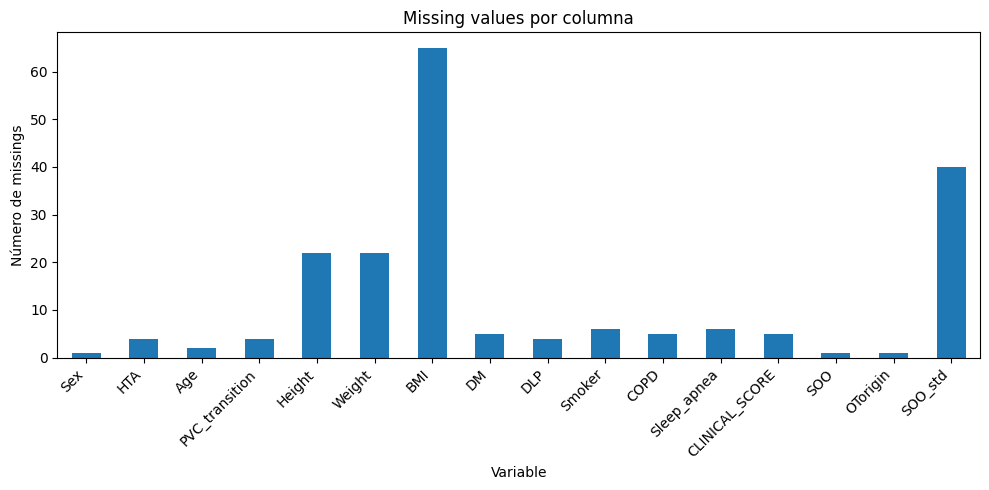


Pacientes después de filtrar: 104
['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin', 'SOO_std']
Sex                1
HTA                4
Age                2
PVC_transition     4
Height            22
Weight            22
BMI               65
DM                 5
DLP                4
Smoker             6
COPD               5
Sleep_apnea        6
CLINICAL_SCORE     5
SOO                1
OTorigin           1
SOO_std           40
dtype: int64


In [27]:
missing = train_set.isnull().sum()
missing = missing[missing > 0]  # solo columnas con missings

# BMI, height and weight can be taken out of the data as it does not really yield important information for the algorithm as most of the values are missing

plt.figure(figsize=(10, 5))
missing.plot(kind='bar')
plt.title('Missing values por columna')
plt.ylabel('Número de missings')
plt.xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPacientes después de filtrar:", len(train_set_ot))
print(train_set_ot.columns.tolist())
print(missing)

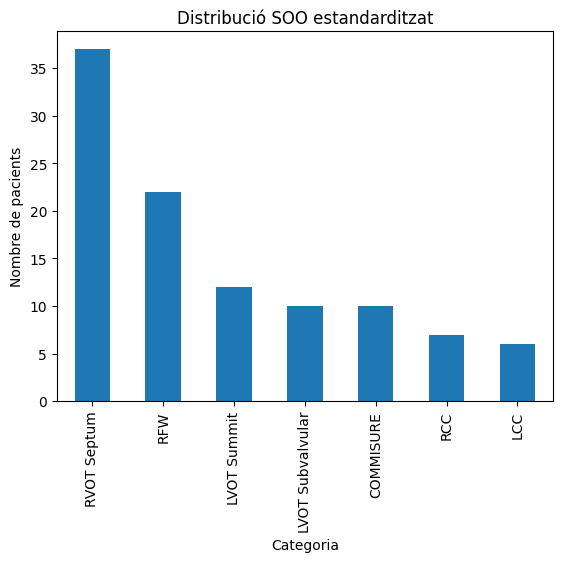

In [28]:
# Gràfic de distribució final
train_set['SOO_std'].value_counts().plot(kind='bar')
plt.title("Distribució SOO estandarditzat")
plt.xlabel("Categoria")
plt.ylabel("Nombre de pacients")
plt.show()

In [29]:
import pandas as pd
import scipy.stats as stats

# 1. Configuració de la divisió de dades
# Suposem que 'SOO' és el teu target. Canvia-ho si té un altre nom.
target_col = 'SOO' 

split_idx = int(0.8 * len(train_set))
train_df = train_set.iloc[:split_idx].copy()
test_df  = train_set.iloc[split_idx:].copy()

# Definir y_train com a Series (important per al .unique())
y_train = train_df[target_col]

# 2. Definició de les variables per tipus
# Hem afegit Weight, Height i BMI aquí
numerical_features = ['Age', 'Weight', 'Height', 'BMI']
ordinal_features   = ['PVC_transition']
binary_features    = ['Sex', 'HTA']

# Mapatge per a variables ordinals (Kruskal-Wallis necessita números, no text)
pvc_map = {val: i for i, val in enumerate(['V1', 'V2', 'V3', 'V4', 'V5', 'V6'])}
train_df['PVC_numeric'] = train_df['PVC_transition'].map(pvc_map)

associations = []

# Afegeix això abans de començar els bucles per assegurar format numèric
for col in numerical_features:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

# Re-inicialitzem la llista de resultats
associations = []

# ── ANOVA robust ──────────────────────────────────────────────────────────
for feature in numerical_features:
    # Filtrem grups: han de tenir dades i més d'un element per ser estadísticament vàlids
    groups = [train_df.loc[y_train == soo, feature].dropna() 
              for soo in y_train.unique()]
    
    # Només fem el test si hi ha almenys 2 grups i cada grup té dades
    groups = [g for g in groups if len(g) > 1]
    
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
    else:
        f_stat, p_value = (None, None) # No hi ha prou dades per al test
        
    associations.append({'Feature': feature, 'Test': 'ANOVA', 'Statistic': f_stat, 'p-value': p_value})

# ── Kruskal-Wallis robust ────────────────────────────────────────────────
for feature in ordinal_features:
    groups = [train_df.loc[y_train == soo, 'PVC_numeric'].dropna() 
              for soo in y_train.unique()]
    
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) > 1:
        h_stat, p_value = stats.kruskal(*groups)
    else:
        h_stat, p_value = (None, None)
        
    associations.append({'Feature': feature, 'Test': 'Kruskal-Wallis', 'Statistic': h_stat, 'p-value': p_value})


# ── Chi-cuadrat per a variables binàries (Sex, HTA) ──────────────────────
for feature in binary_features:
    contingency_table = pd.crosstab(train_df[feature], y_train)
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    associations.append({
        'Feature': feature,
        'Test': 'Chi-cuadrado',
        'Statistic': chi2,
        'p-value': p_value
    })

# ── Resultats ─────────────────────────────────────────────────────────────
df_associations = pd.DataFrame(associations)
df_associations['Significant (p<0.05)'] = df_associations['p-value'] < 0.05

# Ordenem per rellevància (p-value més baix primer)
display(df_associations.sort_values(by='p-value'))

,Feature,Test,Statistic,p-value,Significant (p<0.05)
4,PVC_transition,Kruskal-Wallis,91.809848,0.005143,True
0,Age,ANOVA,2.075749,0.025399,True
6,HTA,Chi-cuadrado,65.736232,0.316253,False
1,Weight,ANOVA,0.871692,0.598270,False
3,BMI,ANOVA,0.758040,0.686520,False
2,Height,ANOVA,0.771038,0.699763,False
5,Sex,Chi-cuadrado,55.111190,0.719942,False


In [30]:
# Eliminem BMI, weight, height -- no tenen relacio i tenen molts de NaNs

train_set = train_set.drop(columns=['BMI', 'Weight', 'Height']) 
# Visualitzar el resultat
display(train_set.head())
print(train_set.shape)

,Sex,HTA,Age,PVC_transition,SOO_chamber,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin,SOO_std
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0,LVOT Subvalvular
1,Female,No,52.0,V3,RVOT,No,No,No,No,No,1.0,Pared libre anterior,1.0,RFW
2,Female,No,69.0,V3,LVOT,No,Yes,No,No,No,1.0,RCC,1.0,RCC
3,Female,No,66.0,V4,Right ventricle,No,No,No,No,No,1.0,M. papilar posteromedial,0.0,NaN
4,Female,Yes,46.0,V3,RVOT,No,No,No,No,No,1.0,RVOT septal,1.0,RVOT Septum


(144, 14)


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
#StandardScaler: media 0, desviacion estandar 1

# DEFINIR FEATURES
numerical_features = ['Age']
ordinal_features   = ['PVC_transition']
binary_features    = ['Sex', 'HTA']
pvc_order = [['V1', 'V2', 'V3', 'V4', 'V5', 'V6']]

# PREPROCESSING PIPELINE
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=pvc_order)),
    #('scaler', StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('ord', ordinal_pipeline,   ordinal_features),
        ('bin', binary_pipeline,    binary_features),
    ],
    remainder='drop'
)


# FIT I TRANSFORM SOLO SOBRE TRAIN
X_train = train_df[numerical_features + ordinal_features + binary_features]
X_train_array = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()
X_train_preprocessed = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train.index
)

print("\nOriginal X_train shape:", X_train.shape)
print("Preprocessed X_train shape:", X_train_preprocessed.shape)
print("\nX_train preprocessed:")
display(X_train_preprocessed.head())


Original X_train shape: (115, 4)
Preprocessed X_train shape: (115, 4)

X_train preprocessed:


,num__Age,ord__PVC_transition,bin__Sex_Male,bin__HTA_Yes
0,0.269483,0.0,0.0,0.0
1,-0.303237,2.0,0.0,0.0
2,0.778567,2.0,0.0,0.0
3,0.587661,3.0,0.0,0.0
4,-0.685051,2.0,0.0,1.0


##### ECG Data Segmentation

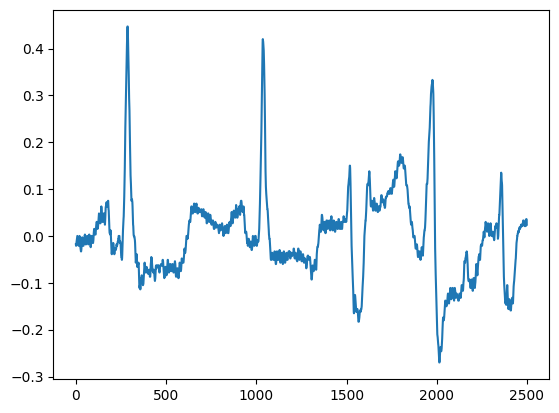

In [32]:
#B. ECG DATA
#The Teknon dataset has ECG signals with 4 beats, the last of which corresponds to the PVC. 
#Using the given segmentation models at models/, you will be able to retrieve all the P, QRS and T waves.

#Of course, you can also use the entire signal as input for your models. In that case, take into account that each lead has different value ranges.
#Moreover, you won't be able to combine your data with the other datasets, since they are segmented in QRS complexes.

#Plot one sample
plt.plot(teknon['I'][0])

In [33]:
#Example with ECG segmentation
import torch
import sak
from functools import partial
import math
import scipy as sp
import skimage
import skimage.util
from typing import List,Tuple
import numpy as np
models_ECG = [
    torch.load(f"models/model.{i+1}") for i in range(5)
]

ModuleNotFoundError: No module named 'sak'

In [191]:
from typing import List
def predict_ecg(ecg: np.ndarray, fs: float, model: List[torch.nn.Module],
                window_size: int = 2048, stride: int = 256, threshold_ensemble: float = 0.5,
                thr_dice=0.9, percentile=95, ptg_voting = 0.5, batch_size = 16,
                normalize=True, norm_threshold: float = 1e-6, filter = True) -> np.ndarray:
    """This function is used to delineate an ECG recording of arbitrary size ('ecg' variable, SAMPLES x LEADS)
    and to obtain the fiducials for the P, QRS and T segments as a binary mask of shape 3 x SAMPLES.

    Inputs:
    ecg                <- some array, e.g. shape 198484 x 12
    fs                 <- sampling frequency, e.g. 1000Hz. Will downsample to 250Hz for the AI model to work
    model              <- list of segmentation models for the ensemble
    window_size        <- the "chunk" size that will be processed at a time of the input ecg (e.g., in the example,
                          2048 samples out of the 198484 samples of the ECG)
    stride             <- the "stride" parameter allows for some overlap between the windows of the window_size
    threshold_ensemble <- Percentage of voting for the AI ensemble [0-1]
    thr_dice           <- Threshold for considering each sample as positive according to the Dice score
    percentile         <- Percentile for the amplitude normalization
    ptg_voting         <- Threshold for considering each sample as positive according to the Dice score
    batch_size         <- Number of windows that fit in the batch
    normalize          <- Boolean to indicate whether the ECG has to be normalized. In general, set this to True
                          always, as the ECGs must have the amplitude of a normal sinus rhythm around amplitude of
                          "1" to work, as that was the preprocessing for model training. Only change if a
                          comparable pre-processing is performed
    norm_threshold     <- Threshold for the normalization, to avoid passing baseline wander or noise as signal
    filter             <- Filter the signal with a band-pass filter in [0.5-125] Hz
    """
    # Preprocess signal
    ecg = np.copy(ecg).squeeze()
    if ecg.ndim == 0:
        return np.array([])
    elif ecg.ndim == 1:
        ecg = ecg[:,None]
    elif ecg.ndim == 2:
        if ecg.shape[0] < ecg.shape[1]:
            ecg = ecg.T
    else:
        raise ValueError("2 dims max allowed")
    
    #Resample to 250Hz if necessary
    if fs != 250:
        ecg_250 = sp.signal.resample(ecg, int(ecg.shape[0]*250/fs), axis=0)
    else:
        ecg_250 = ecg

    # Pad if necessary
    if ecg_250.shape[0] < window_size:
        padding = math.ceil(ecg_250.shape[0]/window_size)*window_size-ecg_250.shape[0]
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')
    if (ecg_250.shape[0]-window_size)%stride != 0:
        padding = math.ceil((ecg_250.shape[0]-window_size)/stride)*stride-(ecg_250.shape[0]%window_size)
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')

    # Get dimensions
    N,L = ecg_250.shape

    # (Optional) Normalize amplitudes
    if normalize:
        # Get ecg_250 when it's not flat zero
        norm_signal = ecg_250[np.all(np.abs(np.diff(ecg_250,axis=0,append=0)) >= norm_threshold,axis=1),:]

        # High pass filter normalized ecg_250 to avoid issues with baseline wander
        norm_signal = sp.signal.filtfilt(*sp.signal.butter(2, 0.5/250., 'high'),norm_signal, axis=0)

        # Compute amplitude for those segments
        amplitude = np.array(sak.signal.moving_lambda(
            norm_signal,
            256,
            partial(sak.signal.amplitude,axis=0),
            axis=0
        ))
        amplitude = amplitude[np.all(amplitude > norm_threshold,axis=1),]
        amplitude = np.percentile(amplitude, percentile, axis=0)

        # Apply normalization
        ecg_250 = ecg_250/amplitude[None,:]

    # (Optional) Filter ecg_250
    if filter:
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2,   0.5/250., 'high'),ecg_250,axis=0)
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, 125.0/250.,  'low'),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(50,20.0,250.),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(60,20.0,250.),ecg_250,axis=0)

    # Avoid issues with negative strides due to filtering:
    if np.any(np.array(ecg_250.strides) < 0):
        ecg_250 = ecg_250.copy()

    # Data structure for computing the segmentation
    windowed_signal = skimage.util.view_as_windows(ecg_250,(window_size,1),(stride,1))

    # Flat batch shape
    new_shape = (windowed_signal.shape[0]*windowed_signal.shape[1],*windowed_signal.shape[2:])
    windowed_signal = np.reshape(windowed_signal,new_shape)

    # Exchange channel position
    windowed_signal = np.swapaxes(windowed_signal,1,2)

    # Output structures
    windowed_mask = np.zeros((windowed_signal.shape[0],3,windowed_signal.shape[-1]),dtype=int)

    # Check device for segmentation
    device = "mps" if torch.backends.mps.is_available() else "cpu"

    # Compute segmentation for all leads independently
    with torch.no_grad():
        if isinstance(model,list):
            for m in model:
                m = m.to(device)
                for i in range(0,windowed_signal.shape[0],batch_size):
                    inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).float().to(device)}
                    outputs = m(inputs)["sigmoid"].cpu().detach().numpy()
                    windowed_mask[i:i+batch_size] += outputs > thr_dice
            windowed_mask = windowed_mask >= len(model)*threshold_ensemble
        else:
            model = model.to(device)
            for i in range(0,windowed_signal.shape[0],batch_size):
                inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).to(device).float()}
                outputs = model(inputs)["sigmoid"].cpu().detach().numpy()
                windowed_mask[i:i+batch_size] = outputs > thr_dice

    # Retrieve mask as 1D
    counter = np.zeros((N), dtype=int)
    segmentation_250 = np.zeros((3,N))

    # Iterate over windows
    for i in range(0,windowed_mask.shape[0],L):
        counter[(i//L)*stride:(i//L)*stride+window_size] += 1
        segmentation_250[:,(i//L)*stride:(i//L)*stride+window_size] += windowed_mask[i:i+L].sum(0)
    segmentation_250 = ((segmentation_250/counter) >= (ecg_250.shape[-1]*ptg_voting))

    # Correct padding
    segmentation_250 = segmentation_250[:,:-padding]

    # Interpolate back to original sampling frequency
    segmentation = sak.signal.interpolate.interp1d(segmentation_250,ecg.shape[0],axis=-1,kind="nearest")

    return segmentation

In [192]:
#Transform the signal from dictionary to numpy array
from sak.signal import StandardHeader
ecg_signals = []
for lead in StandardHeader:
    ecg_signals.append(teknon[lead][0])
ecg_signals = np.asarray(ecg_signals).T

In [193]:
#Apply the segmentation for a single record (make function to apply to multiple signals)
fs = 1000
fs_high,fs_low = 0.5,100.0

#Resample to 250 Hz
ecg_250 = sak.signal.interpolate.interp1d(ecg_signals, round(ecg_signals.shape[0]*250/fs), axis=0).T
#Bandpass filter
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_high/250., 'high'), ecg_250, axis=-1)
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_low/250., 'low'), ecg_250, axis=-1)

#Predict segmentation
segmentation_250 = predict_ecg(ecg_250, 250., models_ECG, normalize=True, filter=False)

#Check for empty segmentation
if segmentation_250.size == 0:
    print(f"[WARN] Empty segmentation")

segmentation = sak.signal.interpolate.interp1d(segmentation_250, ecg_signals.shape[0],axis=-1,kind="nearest")

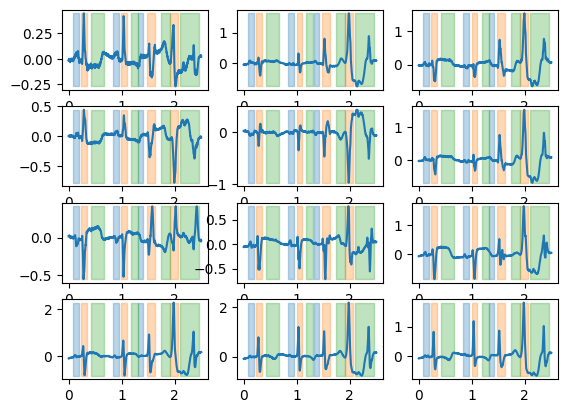

In [194]:
#Plot all the signals
fig, ax = plt.subplots(4,3)
row = 0
col = 0
x = np.linspace(0,2.5,int(fs*2.5))
for i,sig in enumerate(ecg_signals.T):
    ax[row,col].plot(x, sig)
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[0,:] == 1), color='C0', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[1,:] == 1), color='C1', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[2,:] == 1), color='C2', alpha = 0.3 )
    col += 1
    if col >= 3:
        row += 1
        col = 0